In [47]:
import matplotlib.pyplot as plt
import numpy as np
import os
from utilv3 import *
import cv2
import pandas as pd
from pathlib import Path

#for display purposes
def normalize_raster(raster):
    """Normalize raster values to 0–255 for display, returning uint8."""
    raster_min = np.nanmin(raster)
    raster_max = np.nanmax(raster)
    
    if raster_max == raster_min:
        return np.zeros_like(raster, dtype=np.uint8)  # avoid divide by zero
    
    normalized = (raster - raster_min) / (raster_max - raster_min)
    return (normalized * 255).astype(np.uint8)

def update_row(df, key_col, key_val, updates):
    """
    Update a row in a DataFrame by matching key_col == key_val.
    
    Parameters:
    - df: pandas DataFrame
    - key_col: column name to match (e.g., 'id')
    - key_val: value to find in key_col
    - updates: dict of column:value pairs to update
    
    Returns:
    - Updated DataFrame (in place)
    """

    # Add missing columns
    for col in updates.keys():
        if col not in df.columns:
            df[col] = None  # create new column with None values

    mask = df[key_col] == key_val
    if mask.any():
        # Update existing row
        for col, val in updates.items():
            df.loc[mask, col] = val
    else:
        # Build a new row with all columns accounted for
        new_row = {col: None for col in df.columns}
        new_row[key_col] = key_val
        new_row.update(updates)
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)

    return df

Instruction:
Preliminary: Please find the list of FMRs with available images in this file: "...\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\FMR-vectors\fmr_with_images.csv"

0. Kindly change the PATH of the MASTER FILE (replace the "user-.....")
1. Input the image path in "raster_path"
2. Input the centerline path in "vector_path"2.1 Centerline per FMR should be exported from the Master_FMR
2.2 Save exported FMR in "\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\FMR-vectors"
2.3 Exported FMR format: "FMR-##.geojson" 
3. Input the output path in "output_folder" : "\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs"
4. Run Cell 2, check if the image has good quality/suitable for automatic processing.
4.1 If FMR has multiple images, check each image and select the best image available. Proceed to next step.
4.2 If there's no good quality image, kindly note in the csv (mentioned at the top), add remarks column if it does not exist. Run next cell (Cell 3) Proceed to next FMR.
5. Run the next cell (Cell 4).

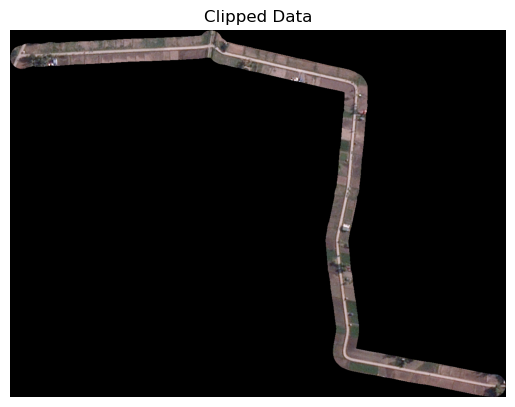

In [ ]:
## FOR one-by-one processing of FMR in compliance to DA-BAFE's request
## Steps 1-4
results = {}

master_file_path = r"C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\FMR-vectors\fmr_with_images.csv"
master_file = pd.read_csv(master_file_path)

raster_path = r"C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\OK BlackSky Images\FMR 28\BSG-115-20240601-230820-244317407_ortho.tif"
vector_path = r"C:\Users\user-307E4B3400\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\OK BlackSky Images\FMR 28\FMR 28 CENTERLINE\FMR_28_centerline.shp"

vector_basename = Path(vector_path).stem    ## gets only the filename; for file/folder naming purposes
vector_gdf = gpd.read_file(vector_path)

output_folder = rf"C:\Users\user-307E4B3400\\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\{vector_basename}"

preprocessor = Preprocessing()
preprocessor.reproject(raster_path)

clipped_data, clipped_transform = preprocessor.clipraster(vector_data=vector_gdf, buffer_dist=25) #bbox=False
clipped_data_box, _ = preprocessor.clipraster(vector_data=vector_gdf, bbox=True) #for exporting purposes

#for display only
display_image = normalize_raster(clipped_data)

plt.imshow(np.moveaxis(display_image, 0, -1))
plt.title("Clipped Data")
plt.axis("off")
plt.show()

##If image is good-to-go proceed to next step

In [ ]:
## ---------- IF image is bad, RUN THIS ------------- ##
results['Remarks'] = ""         #Type here yung remarks on the image

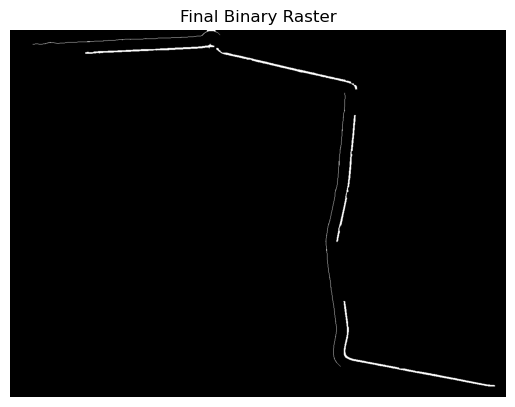

c:\Users\user-307E4B3400\anaconda3\envs\bafe2\lib\site-packages\shapely\constructive.py:181: RuntimeWarning: divide by zero encountered in buffer
  return lib.buffer(


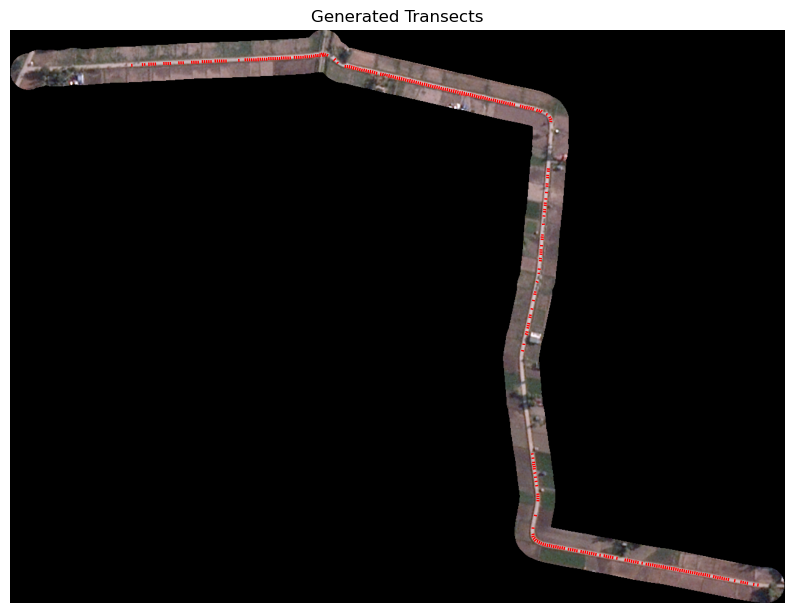

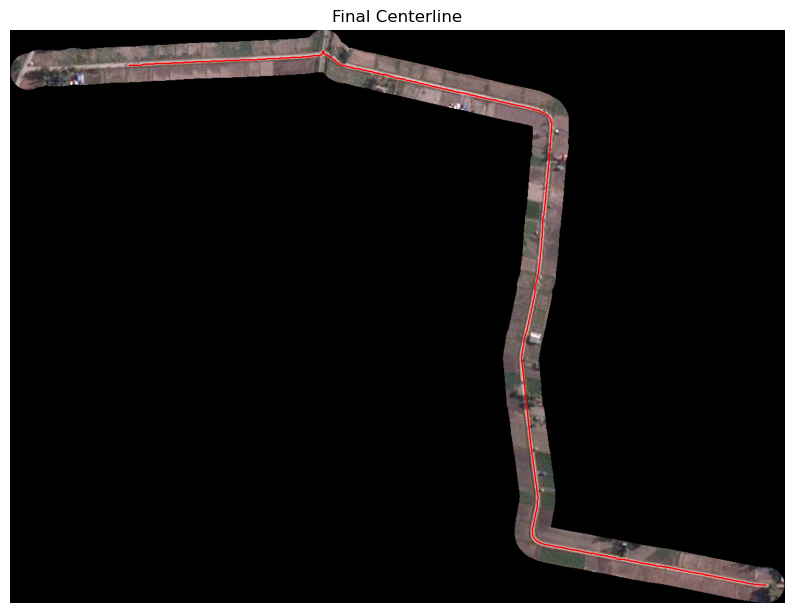

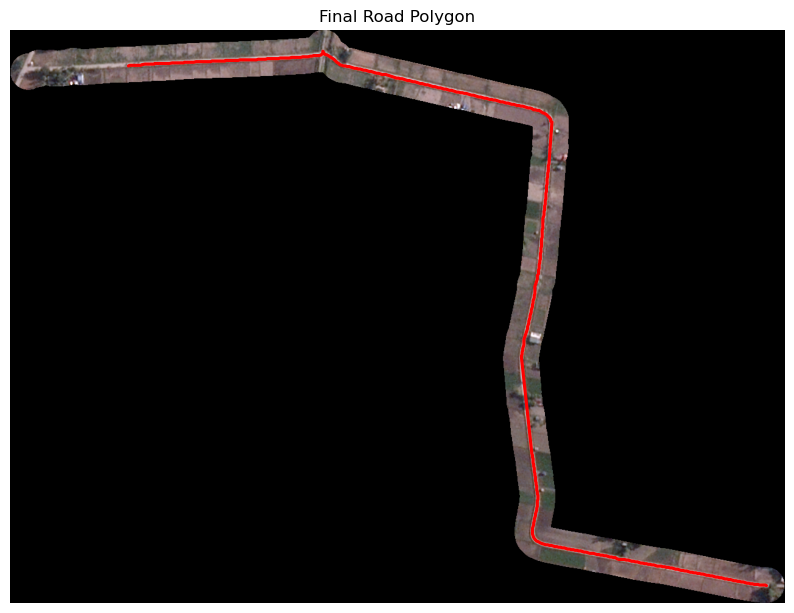

In [48]:
#Processing of the clipped image; filters, morphological operations, viewing results

filter = Filters()
warm_raster = filter.enhance_image_warmth(clipped_data)
stretch_raster = filter.enhance_linear_stretch(clipped_data)

morph = Morph()
morph_warm = morph.process(warm_raster, a=4, b=3, ite1=2, ite2=3)
morph_stretch = morph.process(stretch_raster, a=4, b=3, ite1=2, ite2=3)

merged_or = np.logical_or(morph_warm, morph_stretch)
initial_binary_raster = merged_or

final_binary_transform = clipped_transform

final_binary_raster = morph.remove_small_islands(initial_binary_raster, min_size=500)

#---------------------- Export 1
final_binary_raster = np.squeeze(final_binary_raster)
final_binary_raster = cv2.morphologyEx(final_binary_raster.astype(np.uint8), cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=3) 

plt.imshow(final_binary_raster, cmap="gray")
plt.axis("off")
plt.title("Final Binary Raster")
plt.show()

int, tol, res = 3, 0.15, 0.3

measure = MeasureWidth(final_binary_raster, final_binary_transform, vector_gdf)

#---------------------- Export 2
transects = measure.process(int=int, tol=tol, res=res)
road_mean = transects['width'].mean()

fig, ax = plt.subplots(figsize=(10, 10))
show(display_image, ax=ax, transform=final_binary_transform)
transects.plot(ax=ax, color='red', edgecolor=None, linewidth=1)
ax.set_title("Generated Transects")
ax.axis("off")
plt.show()

# Clip final binary raster for centerline extraction
final_binary_raster, final_binary_transform = preprocessor.clipraster(
                    raster_data = final_binary_raster.astype(np.uint8),
                    vector_data = vector_gdf,
                    transform = clipped_transform,
                    buffer_dist = 3)
final_binary_raster = np.squeeze(final_binary_raster)

# Generate Centerline
#---------------------- Export 3
final_line = measure_line(final_binary_raster, final_binary_transform, spacing=3)

fig, ax = plt.subplots(figsize=(10, 10))
show(display_image, ax=ax, transform=clipped_transform)
final_line.plot(ax=ax, color='red', edgecolor=None, linewidth=1)
ax.set_title("Final Centerline")
ax.axis("off")
plt.show()


# Generate Polygon
#---------------------- Export 4
road_polygon = measure_line(final_binary_raster, final_binary_transform, road_width=road_mean, return_polygon=True)

fig, ax = plt.subplots(figsize=(10, 10))
show(display_image, ax=ax, transform=clipped_transform)
road_polygon.plot(ax=ax, color='red', edgecolor=None, linewidth=1)
ax.set_title("Final Road Polygon")
ax.axis("off")
plt.show()

In [ ]:
actual_length = final_line.length.values[0]
theo_length = vector_gdf.to_crs("EPSG:32651").length.sum()
progress = (actual_length / theo_length) * 100
if theo_length and theo_length > 0:
    progress = float((actual_length / theo_length) * 100.0)
    if progress > 90 and progress < 110:
        status = "Completed"
    elif progress == 0:
        status = "Not Started"
    else:
        status = "On-going"


# Summary of results
results['FMR'] = vector_basename
results['Planned FMR Length'] = theo_length
results['Current FMR Length'] = actual_length
results['FMR Progress'] = progress
results['FMR Status'] = status          #current threshold of this is 10
results['Mean FMR Width'] = measure.transects['width'].mean()
results['Remarks'] = "Test Only"

updated_csv = update_row(master_file, "FMR", vector_basename, results)
updated_csv.to_csv(master_file)


,Unnamed: 0,FMR,BSG,Date,Time,Planned FMR Length,Current FMR Length,FMR Progress,FMR Status,Mean FMR Width,Processing Type,Image Path,Output_Paths,Remarks
0,12,FMR-12,BSG-116-20240822-025910-268851235-Tiff.tif,22/08/2024,2:59:10,1037.107379,NaN,NaN,NaN,NaN,NaN,C:\Users\user-307E4B3400\OneDrive - Philippine...,NaN,None
1,13,FMR-13,BSG-116-20240822-025910-268851235-Tiff.tif,22/08/2024,2:59:10,626.705593,NaN,NaN,NaN,NaN,NaN,C:\Users\user-307E4B3400\OneDrive - Philippine...,NaN,None
2,16,FMR-16,BSG-105-20240820-034800-268155189-Tiff.tif,20/08/2024,3:48:00,1304.931673,NaN,NaN,NaN,NaN,NaN,C:\Users\user-307E4B3400\OneDrive - Philippine...,NaN,None
3,20,FMR-20,BSG-104-20240821-045155-268591266-Tiff.tif,21/08/2024,4:51:55,934.126235,NaN,NaN,NaN,NaN,NaN,C:\Users\user-307E4B3400\OneDrive - Philippine...,NaN,None
4,21,FMR-21,BSG-116-20240822-025850-268851234-Tiff.tif,22/08/2024,2:58:50,1215.638939,NaN,NaN,NaN,NaN,NaN,C:\Users\user-307E4B3400\OneDrive - Philippine...,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,281,FMR-280,BSG-116-20240830-225650-270916242-Tiff.tif,30/08/2024,22:56:50,570.347348,NaN,NaN,NaN,NaN,NaN,C:\Users\user-307E4B3400\OneDrive - Philippine...,NaN,None
59,282,FMR-281,BSG-114-20240621-222830-251195670-Tiff.tif,21/06/2024,22:28:30,377.236414,NaN,NaN,NaN,NaN,NaN,C:\Users\user-307E4B3400\OneDrive - Philippine...,NaN,None
60,293,FMR-292,BSG-116-20240822-030010-268737338-Tiff.tif,22/08/2024,3:00:10,608.547966,NaN,NaN,NaN,NaN,NaN,C:\Users\user-307E4B3400\OneDrive - Philippine...,NaN,None
61,318,FMR-317,BSG-115-20240601-230820-244317407-Tiff.tif,01/06/2024,23:08:20,1678.555362,NaN,NaN,NaN,NaN,NaN,C:\Users\user-307E4B3400\OneDrive - Philippine...,NaN,None


In [50]:
## Exports
# Export clipped RGB image
clipped_image_path = os.path.join(output_folder, f"{vector_basename}_clipped_image.tif")
export(clipped_data_box, clipped_image_path, 'raster', 'EPSG:32651', raster_transform=clipped_transform)

# Export intermediate binary raster
binary_raster_path = os.path.join(output_folder, f"{vector_basename}_binary_raster.tif")
export(final_binary_raster, binary_raster_path, 'raster', 'EPSG:32651', raster_transform=final_binary_transform)

# Export final line (Actual Line)
final_line_path = os.path.join(output_folder, f"{vector_basename}_centerline.shp")
export(final_line, final_line_path, 'vector', 'EPSG:32651')

#Export final polygon (generated from mean width and final centerline)
road_polygon_path = os.path.join(output_folder, f"{vector_basename}_road_polygon.shp")
export(road_polygon, road_polygon_path, 'vector', 'EPSG:32651')



Raster exported successfully to C:\Users\user-307E4B3400\\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\FMR_28_centerline\FMR_28_centerline_clipped_image.tif
Raster exported successfully to C:\Users\user-307E4B3400\\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\FMR_28_centerline\FMR_28_centerline_binary_raster.tif
Vector exported successfully to C:\Users\user-307E4B3400\\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\FMR_28_centerline\FMR_28_centerline_centerline.shp
Vector exported successfully to C:\Users\user-307E4B3400\\OneDrive - Philippine Space Agency\SDMAD_SHARED\PROJECTS\SAKA\FMR\.BAFE - FMR (DPWH)\Outputs\FMR_28_centerline\FMR_28_centerline_road_polygon.shp
